In [1]:
from pathlib import Path

import numpy as np
import yaml

params = yaml.safe_load(Path("../config/robot_params.yaml").read_text())
robot = params["robot"]
act =params["actuator"]
fric = params["friction"]

m = robot["mass_kg"]
izz = robot["izz_kgm2"]
k = robot["half_wheelbase_m"] + robot["half_track_m"]

In [2]:
M = np.array([[1.0, 1.0, 1.0, 1.0], [-1.0, 1.0, 1.0, -1.0], [-k, k, -k, k],])
M_pinv = np.linalg.pinv(M)

def wrench_to_wheel_forces(wrench):
    return M_pinv @ wrench

def wheel_forces_to_wrench(forces):
    return M @ forces

In [3]:
def apply_actuator_limits(forces, f_max):
    return np.clip(forces, -f_max, f_max)

def apply_friction(forces, mu_s, mu_k, normal_force):
    grip = mu_s * normal_force
    slipping = np.abs(forces) > grip
    capped = forces.copy()
    capped[slipping] = np.sign(forces[slipping]) * mu_k * normal_force
    return capped


In [4]:
def dynamics(state, wrench):
    _, _, theta, vx, vy, omega = state
    fx, fy, mz = wrench
    return np.array([
        vx * np.cos(theta) - vy * np.sin(theta),
        vx * np.sin(theta) + vy * np.cos(theta),
        omega,
        fx / m + vy * omega,
        fy / m - vx * omega,
        mz / izz,
    ])

In [5]:
def rk4_step(state, wrench, dt):
    k1 = dynamics(state, wrench)
    k2 = dynamics(state + 0.5 * dt * k1, wrench)
    k3 = dynamics(state + 0.5 * dt * k2, wrench)
    k4 = dynamics(state + dt * k3, wrench)
    return state + (dt/ 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def plant_step(state, wrench_cmd, dt):
    forces = wrench_to_wheel_forces(np.asarray(wrench_cmd, dtype=float))
    forces = apply_actuator_limits(forces, act["wheel_force_max_n"])
    forces = apply_friction(forces, fric["mu_static"], fric["mu_kinetic"], m*9.81/4)
    wrench = wheel_forces_to_wrench(forces)
    return rk4_step(state, wrench, dt), wrench

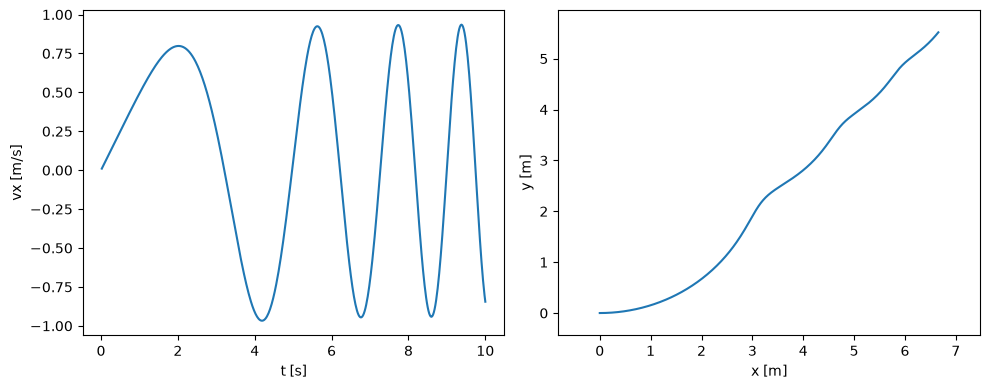

In [6]:
import matplotlib.pyplot as plt

def rollout(wrench_cmd, n_steps=500, dt=0.02):
    state = np.zeros(6)
    log = np.zeros((n_steps, 6))
    for i in range(n_steps):
        state, _ = plant_step(state, wrench_cmd, dt)
        log[i] = state
    return np.arange(1, n_steps + 1) * dt, log

t, log = rollout([40.0, 0.0, 5])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(t, log[:, 3])
axes[0].set(xlabel="t [s]", ylabel="vx [m/s]")
axes[1].plot(log[:, 0], log[:, 1])
axes[1].axis("equal")
axes[1].set(xlabel="x [m]", ylabel="y [m]")
plt.tight_layout()

In [7]:
def circle_ref(t, radius = 2.0, period = 20.0):
    w = 2*np.pi/period
    x = radius*np.cos(w*t)
    y = radius*np.sin(w*t)
    heading = np.arctan2(np.gradient(y,t), np.gradient(x,t))
    return np.column_stack([x, y, heading])

def figure8_ref(t, scale = 2.0, period = 30.0):
    w = 2*np.pi/period
    x = scale * np.sin(w*t)
    y =0.5*scale*np.sin(2*w*t)
    heading = np.arctan2(np.gradient(y,t), np.gradient(x,t))
    return np.column_stack([x, y, heading])

def waypoint_ref(t, points=((2.0, 0.0),(2.0, 2.0), (0.0, 2.0), (0.0, 0.0)), hold = 5.0):
    pts = np.asarray(points)
    idx = np.minimum((t/hold).astype(int), len(pts) - 1)
    return np.column_stack([pts[idx], np.zeros(len(t))])



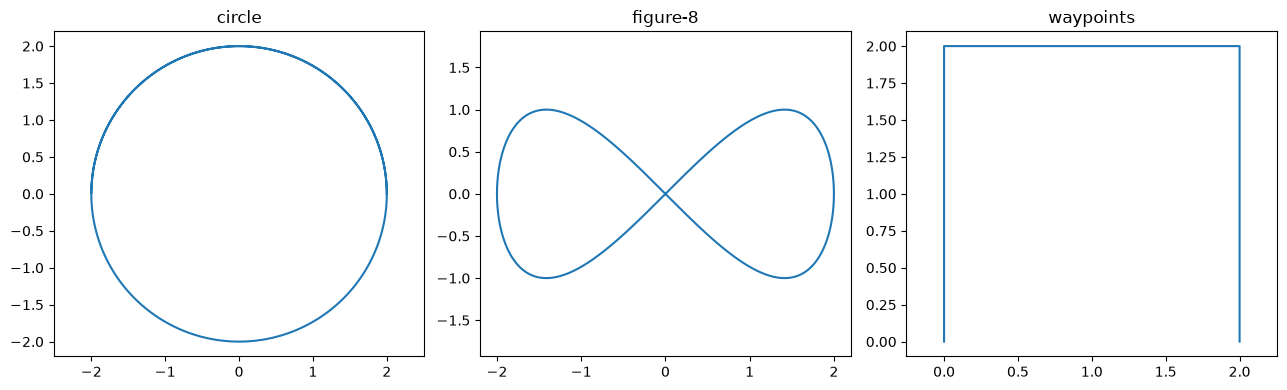

In [8]:
t = np.arange(0.0, 30.0, 0.02)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, ref, name in zip(
    axes,
    [circle_ref(t), figure8_ref(t), waypoint_ref(t)],
    ["circle", "figure-8", "waypoints"],
):
    ax.plot(ref[:, 0], ref[:, 1])
    ax.axis("equal")
    ax.set_title(name)
plt.tight_layout()